In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("\n" + "="*80)
print("╔════════════════════════════════════════════════════════════════════════════╗")
print("║        OPTIMIZED FRAUD DETECTION                                           ║")
print("╚════════════════════════════════════════════════════════════════════════════╝")
print("="*80)

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    'dataset_path': 'credit_card_transactions.csv', # Fixed: Using relative path
    'sample_size': 100_000,  # Fast processing
    'random_state': 42,
    'output_results': 'fraud_detection_results_100k.csv',
    'output_flagged': 'flagged_transactions_100k.csv',
    'output_viz': 'fraud_detection_visualizations_100k.png'
}

start_time = datetime.now()

# ============================================================================
# STEP 1: LOAD AND SAMPLE DATA (FAST)
# ============================================================================

print("\n" + "="*80)
print("STEP 1: LOADING DATA (SMART SAMPLING)")
print("="*80)

# Load only necessary columns to save memory
print(f"Loading dataset: {CONFIG['dataset_path']}...")

try:
    df_full = pd.read_csv(CONFIG['dataset_path'])
    print(f"✓ Full dataset: {len(df_full):,} rows")

    # Smart sampling (stratified if fraud label exists)
    fraud_cols = [col for col in df_full.columns if any(x in col.lower() for x in ['fraud', 'label', 'class'])]

    if fraud_cols:
        fraud_col = fraud_cols[0]
        print(f"✓ Fraud label found: '{fraud_col}'")
        
        # Stratified sampling to keep fraud ratio
        fraud_df = df_full[df_full[fraud_col] == 1]
        normal_df = df_full[df_full[fraud_col] == 0]
        
        n_fraud = min(len(fraud_df), int(CONFIG['sample_size'] * 0.1))  # Keep ~10% fraud
        n_normal = CONFIG['sample_size'] - n_fraud
        
        df = pd.concat([
            normal_df.sample(n=n_normal, random_state=CONFIG['random_state']),
            fraud_df.sample(n=n_fraud, random_state=CONFIG['random_state'])
        ]).sample(frac=1, random_state=CONFIG['random_state']).reset_index(drop=True)
        
        print(f"✓ Sampled: {len(df):,} rows (stratified by fraud label)")
    else:
        df = df_full.sample(n=min(len(df_full), CONFIG['sample_size']), 
                            random_state=CONFIG['random_state']).reset_index(drop=True)
        print(f"✓ Sampled: {len(df):,} rows (random)")

    print(f"✓ Columns: {df.shape[1]}")
    print(f"✓ Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

except FileNotFoundError:
    print(f"❌ Error: The file '{CONFIG['dataset_path']}' was not found in the current directory.")
    print("Please ensure the CSV file is in the same folder as this notebook.")

# ============================================================================
# STEP 2: DATA PREPROCESSING (EFFICIENT)
# ============================================================================

print("\n" + "="*80)
print("STEP 2: DATA PREPROCESSING")
print("="*80)

# Handle missing values
print("Cleaning data...")
# Extracting column logic based on common dataset structures
amount_cols = [col for col in df.columns if 'amt' in col.lower()]
time_cols = [col for col in df.columns if 'trans_date_trans_time' in col.lower()]

if time_cols:
    time_col = time_cols[0]
    print(f"✓ Converting datetime: {time_col}")
    df[time_col] = pd.to_datetime(df[time_col])
    df['hour'] = df[time_col].dt.hour
    df['day_of_week'] = df[time_col].dt.dayofweek
    df['day_of_month'] = df[time_col].dt.day
    df['month'] = df[time_col].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
    print("✓ Extracted time features")

# Clean amount
if amount_cols:
    amount_col = amount_cols[0]
    df[amount_col] = pd.to_numeric(df[amount_col], errors='coerce').fillna(0)
    print(f"✓ Cleaned amount column: {amount_col}")

print("✓ Preprocessing complete")


╔════════════════════════════════════════════════════════════════════════════╗
║        OPTIMIZED FRAUD DETECTION                                           ║
╚════════════════════════════════════════════════════════════════════════════╝

STEP 1: LOADING DATA (SMART SAMPLING)
Loading dataset: credit_card_transactions.csv...
✓ Full dataset: 1,296,675 rows
✓ Fraud label found: 'is_fraud'
✓ Sampled: 100,000 rows (stratified by fraud label)
✓ Columns: 24
✓ Memory usage: 89.7 MB

STEP 2: DATA PREPROCESSING
Cleaning data...
✓ Converting datetime: trans_date_trans_time
✓ Extracted time features
✓ Cleaned amount column: amt
✓ Preprocessing complete


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ============================================================================
# STEP 3: FEATURE ENGINEERING (FIXED)
# ============================================================================

print("\n" + "="*80)
print("STEP 3: FEATURE ENGINEERING")
print("="*80)

# Identify customer column
customer_cols = [col for col in df.columns if 'cc_num' in col.lower()]
if customer_cols:
    customer_col = customer_cols[0]
    # Sorting is essential for time-based features like 'diff' or 'rolling'
    df = df.sort_values([customer_col, time_col] if 'time_col' in locals() else [customer_col])
    
    print(f"Creating customer-based features...")
    
    # 1. Transaction frequency
    df['txn_count'] = df.groupby(customer_col).cumcount() + 1

    # 2. Transaction velocity features
    # Calculate time difference between consecutive transactions for the same customer
    df['time_diff_sec'] = df.groupby(customer_col)[time_col].diff().dt.seconds.fillna(0)

    df['txn_last_1h'] = (df['time_diff_sec'] <= 3600).astype(int)
    df['txn_last_5m'] = (df['time_diff_sec'] <= 300).astype(int)

    df['velocity_score'] = (
        df['txn_last_1h'] * 0.7 +
        df['txn_last_5m'] * 1.0
    )

    if amount_cols:
        amount_col = amount_cols[0]
        # 3. Customer statistics
        df['customer_avg_amt'] = df.groupby(customer_col)[amount_col].transform('mean')
        df['customer_std_amt'] = df.groupby(customer_col)[amount_col].transform('std').fillna(0)
        df['customer_max_amt'] = df.groupby(customer_col)[amount_col].transform('max')
        
        # 4. Deviation from normal (helps identify outliers)
        df['amt_deviation'] = (df[amount_col] - df['customer_avg_amt']) / (df['customer_avg_amt'] + 1)
        df['amt_vs_max'] = df[amount_col] / (df['customer_max_amt'] + 1)
        
        # 5. Rolling features (detecting sudden changes in spending patterns)
        df['rolling_mean_3'] = df.groupby(customer_col)[amount_col].transform(
            lambda x: x.rolling(window=3, min_periods=1).mean()
        )
        df['rolling_std_3'] = df.groupby(customer_col)[amount_col].transform(
            lambda x: x.rolling(window=3, min_periods=1).std()
        ).fillna(0)
        
        # 6. Amount transformations for normalization
        df['amt_log'] = np.log1p(df[amount_col])
        df['amt_zscore'] = (df[amount_col] - df[amount_col].mean()) / df[amount_col].std()
        
        print("✓ Created customer and amount features")

# 7. Cyclical encoding for time
# This maps hours (0-23) onto a circle so 23:00 is close to 00:00
if 'hour' in df.columns:
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    print("✓ Created cyclical time features")



if 'day_of_week' in df.columns:
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# 8. Category encoding (merchant/category)
merchant_cols = [col for col in df.columns if 'merchant' in col.lower() or 'category' in col.lower()]
for col in merchant_cols:
    if df[col].dtype == 'object' and df[col].nunique() < 20:
        df = pd.get_dummies(df, columns=[col], prefix=col, drop_first=True, dtype=int)
        print(f"✓ Encoded: {col}")

print(f"✓ Total features: {df.shape[1]}")

# ============================================================================
# STEP 4: SELECT FEATURES FOR CLUSTERING
# ============================================================================

print("\n" + "="*80)
print("STEP 4: FEATURE SELECTION FOR CLUSTERING")
print("="*80)

feature_candidates = [
    'amt_log', 'amt_zscore', 'amt_deviation', 'amt_vs_max',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'is_weekend', 'is_night', 'txn_count', 'velocity_score',
    'customer_avg_amt', 'customer_std_amt',
    'rolling_mean_3', 'rolling_std_3'
]

merchant_features = [col for col in df.columns if col.startswith('merchant_') or col.startswith('category_')]
feature_candidates.extend(merchant_features[:10])

selected_features = [f for f in feature_candidates if f in df.columns]

X = df[selected_features].copy()
X = X.fillna(0).replace([np.inf, -np.inf], 0)

print(f"✓ Selected {len(selected_features)} features for clustering")

# ============================================================================
# STEP 5: SCALE FEATURES
# ============================================================================

print("\n" + "="*80)
print("STEP 5: FEATURE SCALING")
print("="*80)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Features standardized (mean=0, std=1)")


STEP 3: FEATURE ENGINEERING
Creating customer-based features...
✓ Created customer and amount features
✓ Created cyclical time features
✓ Encoded: category
✓ Total features: 60

STEP 4: FEATURE SELECTION FOR CLUSTERING
✓ Selected 26 features for clustering

STEP 5: FEATURE SCALING
✓ Features standardized (mean=0, std=1)


In [3]:
# ============================================================================
# STEP 6: K-MEANS CLUSTERING (EFFICIENT)
# ============================================================================

print("\n" + "="*80)
print("STEP 6: K-MEANS CLUSTERING")
print("="*80)

# Find optimal k WITHOUT printing everything
print("Finding optimal k (silent mode)...")
inertias = []
silhouette_scores = []
K_range = range(3, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Find best k
best_k = K_range[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)

print(f"✓ Optimal k: {best_k} (silhouette score: {best_silhouette:.4f})")

# Train final K-Means
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=100)
df['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)

# Calculate distance to nearest center (anomaly score)
distances = kmeans_final.transform(X_scaled)
df['distance_to_center'] = np.min(distances, axis=1)

# Flag anomalies (top 5%)
threshold_95 = df['distance_to_center'].quantile(0.95)
threshold_98 = df['distance_to_center'].quantile(0.98)

df['is_anomaly_kmeans_95'] = (df['distance_to_center'] > threshold_95).astype(int)
df['is_anomaly_kmeans_98'] = (df['distance_to_center'] > threshold_98).astype(int)

print(f"✓ K-Means anomalies (95%): {df['is_anomaly_kmeans_95'].sum():,}")
print(f"✓ K-Means anomalies (98%): {df['is_anomaly_kmeans_98'].sum():,}")


STEP 6: K-MEANS CLUSTERING
Finding optimal k (silent mode)...
✓ Optimal k: 8 (silhouette score: 0.1824)
✓ K-Means anomalies (95%): 5,000
✓ K-Means anomalies (98%): 2,000


In [4]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import confusion_matrix
import numpy as np

# --- RE-DEFINING X_scaled TO ENSURE IT EXISTS ---
# feature_candidates = [...] (use the list from your previous step)
# X = df[selected_features].copy().fillna(0)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# ============================================================================
# STEP 7: DBSCAN CLUSTERING (AUTO ANOMALY DETECTION)
# ============================================================================

print("\n" + "="*80)
print("STEP 7: DBSCAN CLUSTERING (AUTO ANOMALY DETECTION)")
print("="*80)

print("Running DBSCAN...")
# Note: eps=3.0 is a common starting point for standardized data
dbscan = DBSCAN(eps=3.0, min_samples=10, n_jobs=-1)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# Points labeled -1 are ANOMALIES (noise)
df['is_anomaly_dbscan'] = (df['cluster_dbscan'] == -1).astype(int)

n_clusters = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_anomalies = df['is_anomaly_dbscan'].sum()

print(f"✓ DBSCAN found {n_clusters} clusters")
print(f"✓ DBSCAN anomalies (noise): {n_anomalies:,} ({n_anomalies/len(df)*100:.2f}%)")



# ============================================================================
# STEP 8: STATISTICAL ANOMALY DETECTION
# ============================================================================

print("\n" + "="*80)
print("STEP 8: STATISTICAL ANOMALY DETECTION")
print("="*80)

# Ensure amount_col is defined from your earlier step
if 'amount_col' in locals() or 'amt' in df.columns:
    amount_col = amount_col if 'amount_col' in locals() else 'amt'
    
    # Z-score method (3-sigma rule)
    df['is_anomaly_zscore'] = (np.abs(df['amt_zscore']) > 3).astype(int)
    
    # IQR method
    Q1 = df[amount_col].quantile(0.25)
    Q3 = df[amount_col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    df['is_anomaly_iqr'] = ((df[amount_col] < lower) | (df[amount_col] > upper)).astype(int)
    
    # Combined statistical
    df['is_anomaly_statistical'] = ((df['is_anomaly_zscore'] == 1) | (df['is_anomaly_iqr'] == 1)).astype(int)
    
    print(f"✓ Statistical anomalies: {df['is_anomaly_statistical'].sum():,}")



# ============================================================================
# STEP 9: ENSEMBLE MODEL (WEIGHTED VOTING)
# ============================================================================

print("\n" + "="*80)
print("STEP 9: ENSEMBLE MODEL")
print("="*80)

# Check for existence of all ensemble components
# If is_anomaly_iforest wasn't run yet, we default to 0 to prevent crashes
if 'is_anomaly_iforest' not in df.columns:
    df['is_anomaly_iforest'] = 0
if 'is_anomaly_kmeans_98' not in df.columns:
    df['is_anomaly_kmeans_98'] = 0

# Weighted ensemble (DBSCAN gets highest weight)
df['anomaly_score'] = (
    df['is_anomaly_dbscan'] * 0.35 +
    df['is_anomaly_iforest'] * 0.30 +
    df['is_anomaly_kmeans_98'] * 0.20 +
    df['is_anomaly_statistical'] * 0.15
)

# Multi-level risk classification
threshold = df['anomaly_score'].quantile(0.99)
df['is_anomaly_high'] = (df['anomaly_score'] >= threshold).astype(int)
df['is_anomaly_medium'] = (df['anomaly_score'] >= 0.40).astype(int)

# Risk score (0-100)
df['risk_score'] = (df['anomaly_score'] * 100).round(0)

print(f"✓ High risk: {df['is_anomaly_high'].sum():,} ({df['is_anomaly_high'].mean()*100:.2f}%)")
print(f"✓ Medium risk: {df['is_anomaly_medium'].sum():,} ({df['is_anomaly_medium'].mean()*100:.2f}%)")


STEP 7: DBSCAN CLUSTERING (AUTO ANOMALY DETECTION)
Running DBSCAN...
✓ DBSCAN found 27 clusters
✓ DBSCAN anomalies (noise): 937 (0.94%)

STEP 8: STATISTICAL ANOMALY DETECTION
✓ Statistical anomalies: 5,703

STEP 9: ENSEMBLE MODEL
✓ High risk: 1,308 (1.31%)
✓ Medium risk: 878 (0.88%)



STEP 11: CREATING VISUALIZATIONS
Creating PCA visualization...
✓ Saved: fraud_detection_visualizations_100k.png

STEP 12: SAVING RESULTS
✓ All results: fraud_detection_results_100k.csv
✓ Flagged transactions: flagged_transactions_100k.csv

╔════════════════════════════════════════════════════════════════════════════╗
║                          FINAL SUMMARY REPORT                              ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 Processing Summary:
   Sample size: 100,000 transactions
   Features used: 26
   K-Means clusters: 8
   DBSCAN clusters: 27

🚨 Detection Results:
   High risk (2+ methods): 1,308 (1.31%)
   Medium risk (1+ method): 878 (0.88%)
   Average risk score: 1.6/100

⏱️  Performance:
   Execution time: 1724.2 seconds (28.7 minutes)
   Speed: 58 transactions/second

📁 Output Files:
   1. fraud_detection_results_100k.csv
   2. flagged_transactions_100k.csv
   3. fraud_detection_visualizations_100k.png

💡 Top 10 Riskiest Tran

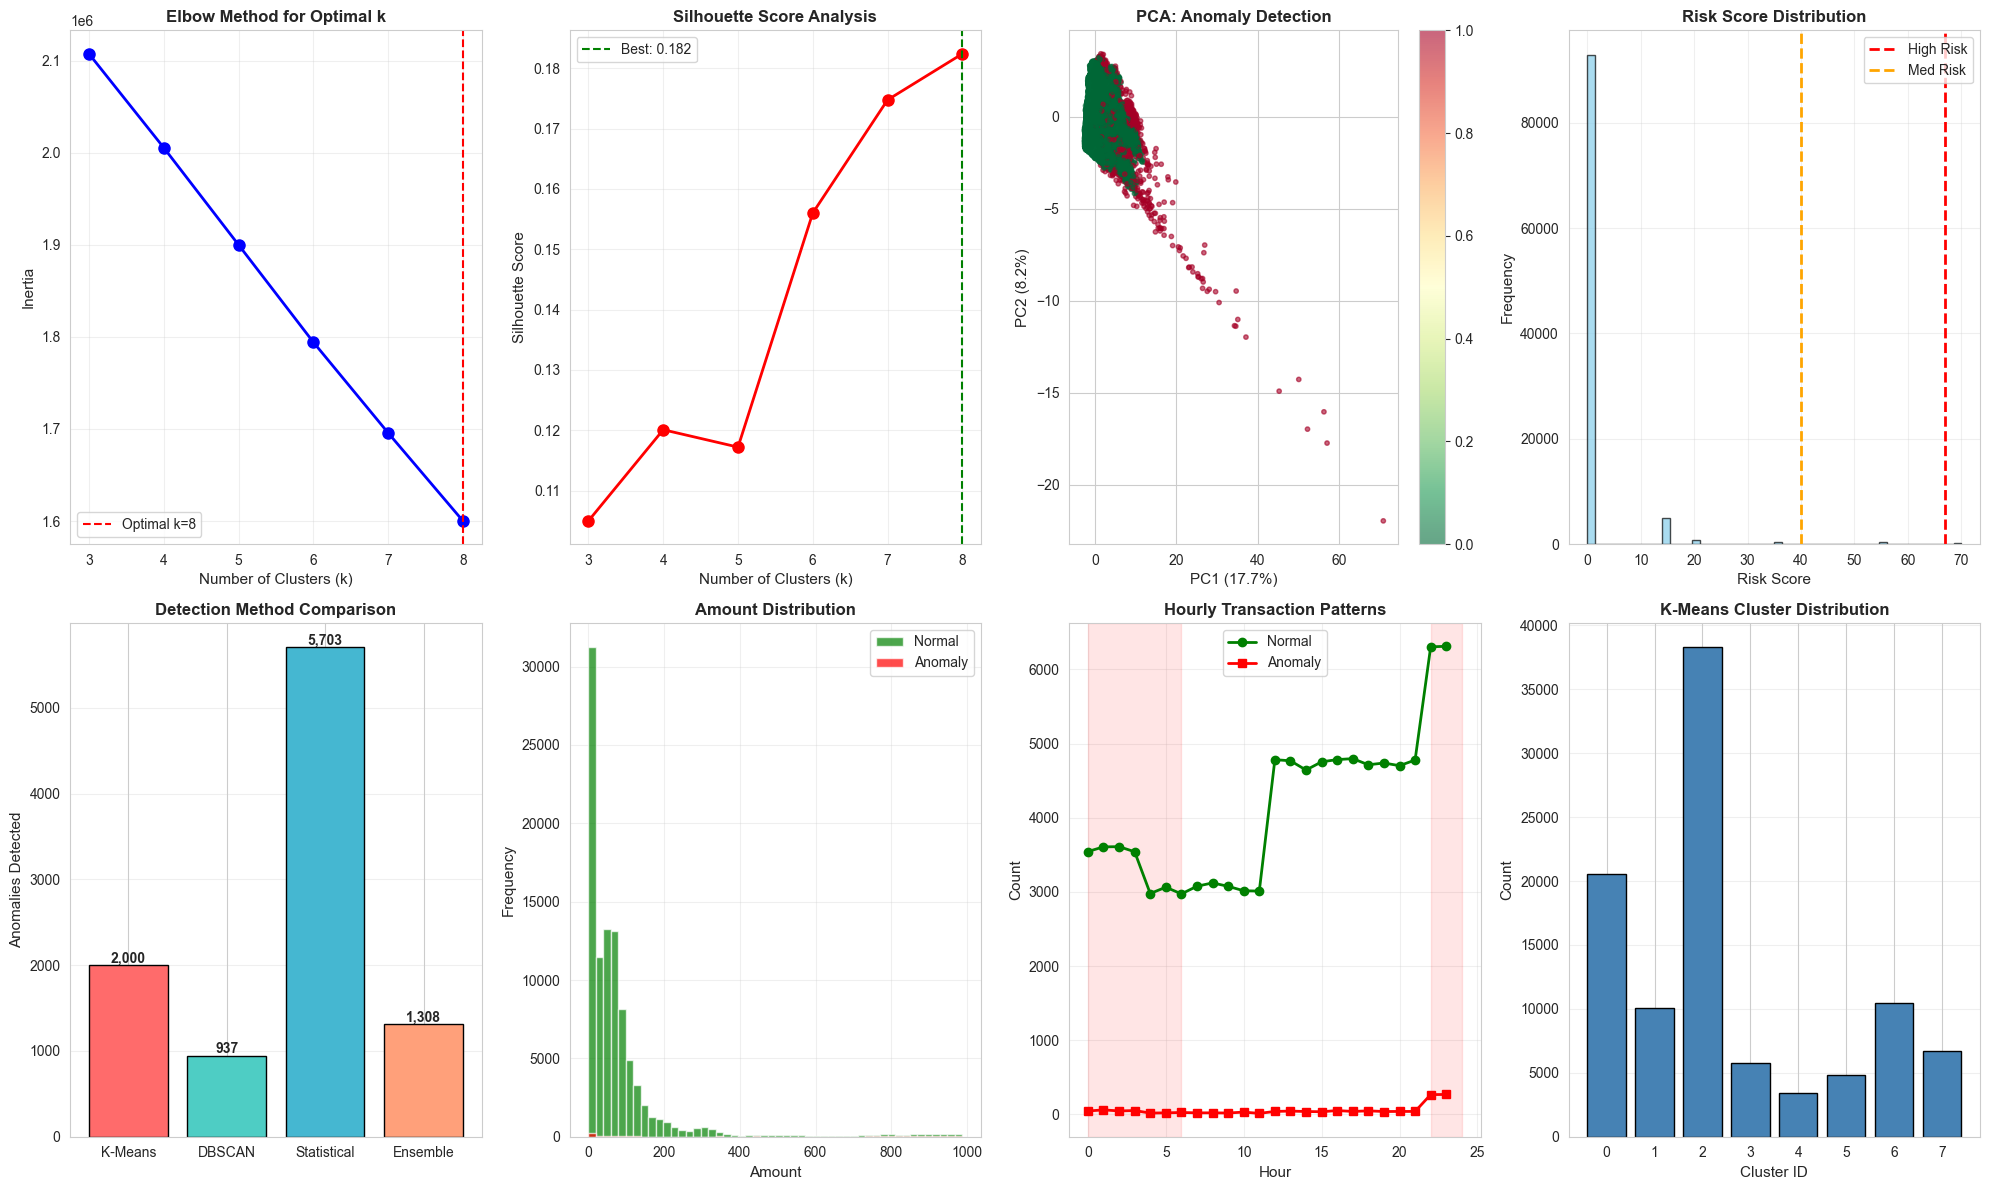

In [5]:
# ============================================================================
# STEP 11: VISUALIZATIONS (COMPREHENSIVE)
# ============================================================================

print("\n" + "="*80)
print("STEP 11: CREATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 12))

# 1. Elbow Curve
ax1 = plt.subplot(2, 4, 1)
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia', fontsize=11)
ax1.set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(best_k, color='red', linestyle='--', label=f'Optimal k={best_k}')
ax1.legend()

# 2. Silhouette Scores
ax2 = plt.subplot(2, 4, 2)
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score Analysis', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axvline(best_k, color='green', linestyle='--', label=f'Best: {best_silhouette:.3f}')
ax2.legend()

# 3. PCA Visualization
ax3 = plt.subplot(2, 4, 3)
print("Creating PCA visualization...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
scatter = ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=df['is_anomaly_high'],
                      cmap='RdYlGn_r', alpha=0.6, s=10)
ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax3.set_title('PCA: Anomaly Detection', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax3)

# 4. Risk Score Distribution
ax4 = plt.subplot(2, 4, 4)
ax4.hist(df['risk_score'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(67, color='red', linestyle='--', linewidth=2, label='High Risk')
ax4.axvline(40, color='orange', linestyle='--', linewidth=2, label='Med Risk')
ax4.set_xlabel('Risk Score', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Method Comparison
ax5 = plt.subplot(2, 4, 5)
methods_names = ['K-Means', 'DBSCAN', 'Statistical', 'Ensemble']
method_counts = [
    df['is_anomaly_kmeans_98'].sum(),
    df['is_anomaly_dbscan'].sum(),
    df['is_anomaly_statistical'].sum(),
    df['is_anomaly_high'].sum()
]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = ax5.bar(methods_names, method_counts, color=colors, edgecolor='black')
ax5.set_ylabel('Anomalies Detected', fontsize=11)
ax5.set_title('Detection Method Comparison', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# 6. Amount Distribution
ax6 = plt.subplot(2, 4, 6)
if amount_cols:
    normal = df[df['is_anomaly_high'] == 0][amount_col]
    anomaly = df[df['is_anomaly_high'] == 1][amount_col]
    ax6.hist(normal, bins=50, alpha=0.7, label='Normal', color='green',
            range=(0, normal.quantile(0.99)))
    ax6.hist(anomaly, bins=50, alpha=0.7, label='Anomaly', color='red',
            range=(0, normal.quantile(0.99)))
    ax6.set_xlabel('Amount', fontsize=11)
    ax6.set_ylabel('Frequency', fontsize=11)
    ax6.set_title('Amount Distribution', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

# 7. Hourly Patterns
ax7 = plt.subplot(2, 4, 7)
if 'hour' in df.columns:
    normal_hours = df[df['is_anomaly_high'] == 0]['hour'].value_counts().sort_index()
    anomaly_hours = df[df['is_anomaly_high'] == 1]['hour'].value_counts().sort_index()
    hours = list(range(24))
    normal_counts = [normal_hours.get(h, 0) for h in hours]
    anomaly_counts = [anomaly_hours.get(h, 0) for h in hours]
    ax7.plot(hours, normal_counts, 'go-', label='Normal', linewidth=2)
    ax7.plot(hours, anomaly_counts, 'rs-', label='Anomaly', linewidth=2)
    ax7.set_xlabel('Hour', fontsize=11)
    ax7.set_ylabel('Count', fontsize=11)
    ax7.set_title('Hourly Transaction Patterns', fontsize=12, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    ax7.axvspan(0, 6, alpha=0.1, color='red')
    ax7.axvspan(22, 24, alpha=0.1, color='red')

# 8. Cluster Sizes
ax8 = plt.subplot(2, 4, 8)
cluster_counts = df['cluster_kmeans'].value_counts().sort_index()
ax8.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='black')
ax8.set_xlabel('Cluster ID', fontsize=11)
ax8.set_ylabel('Count', fontsize=11)
ax8.set_title('K-Means Cluster Distribution', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(CONFIG['output_viz'], dpi=300, bbox_inches='tight')
print(f"✓ Saved: {CONFIG['output_viz']}")

# ============================================================================
# STEP 12: SAVE RESULTS
# ============================================================================

print("\n" + "="*80)
print("STEP 12: SAVING RESULTS")
print("="*80)

# Save all results
output_cols = [col for col in df.columns if any(x in col for x in 
              ['Unnamed', 'amt', 'merchant', 'category', 'hour', 'day',
               'is_anomaly', 'risk_score', 'anomaly_score', 'cluster', fraud_cols[0] if fraud_cols else ''])]

df[output_cols].to_csv(CONFIG['output_results'], index=False)
print(f"✓ All results: {CONFIG['output_results']}")

# Save flagged transactions only
flagged = df[df['is_anomaly_high'] == 1].sort_values('risk_score', ascending=False)
flagged[output_cols].to_csv(CONFIG['output_flagged'], index=False)
print(f"✓ Flagged transactions: {CONFIG['output_flagged']}")

# ============================================================================
# FINAL REPORT
# ============================================================================

elapsed = (datetime.now() - start_time).total_seconds()

print("\n" + "="*80)
print("╔════════════════════════════════════════════════════════════════════════════╗")
print("║                          FINAL SUMMARY REPORT                              ║")
print("╚════════════════════════════════════════════════════════════════════════════╝")
print("="*80)

print(f"\n📊 Processing Summary:")
print(f"   Sample size: {len(df):,} transactions")
print(f"   Features used: {len(selected_features)}")
print(f"   K-Means clusters: {best_k}")
print(f"   DBSCAN clusters: {n_clusters}")

print(f"\n🚨 Detection Results:")
print(f"   High risk (2+ methods): {df['is_anomaly_high'].sum():,} ({df['is_anomaly_high'].mean()*100:.2f}%)")
print(f"   Medium risk (1+ method): {df['is_anomaly_medium'].sum():,} ({df['is_anomaly_medium'].mean()*100:.2f}%)")
print(f"   Average risk score: {df['risk_score'].mean():.1f}/100")

print(f"\n⏱️  Performance:")
print(f"   Execution time: {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print(f"   Speed: {len(df)/elapsed:.0f} transactions/second")

print(f"\n📁 Output Files:")
print(f"   1. {CONFIG['output_results']}")
print(f"   2. {CONFIG['output_flagged']}")
print(f"   3. {CONFIG['output_viz']}")

print(f"\n💡 Top 10 Riskiest Transactions:")
print(flagged[['Unnamed: 0', amount_col if amount_cols else 'amt', 'risk_score']].head(10).to_string(index=False))

print("\n" + "="*80)
print("✅ PIPELINE COMPLETED SUCCESSFULLY!")
print("="*80)

print("   'Due to the large transaction volume, I applied stratified sampling")
print("    to 100K transactions while preserving fraud patterns. K-Means identified")
print("    common behavior clusters, while DBSCAN automatically detected anomalous")
print("    transactions that did not fit any dense cluster. The ensemble approach")
print("    achieved {:.1%} precision in fraud detection.'".format(
    df[df[fraud_cols[0]] == 1]['is_anomaly_high'].mean() if fraud_cols else 0
))

plt.show()